<a href="https://colab.research.google.com/github/araoclaudio2-create/Assignment-AI-2/blob/main/Final_Project_Intro_to_Ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

# Load dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target

# Basic info
print(df.info())
print(df.describe())

# Check missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
2

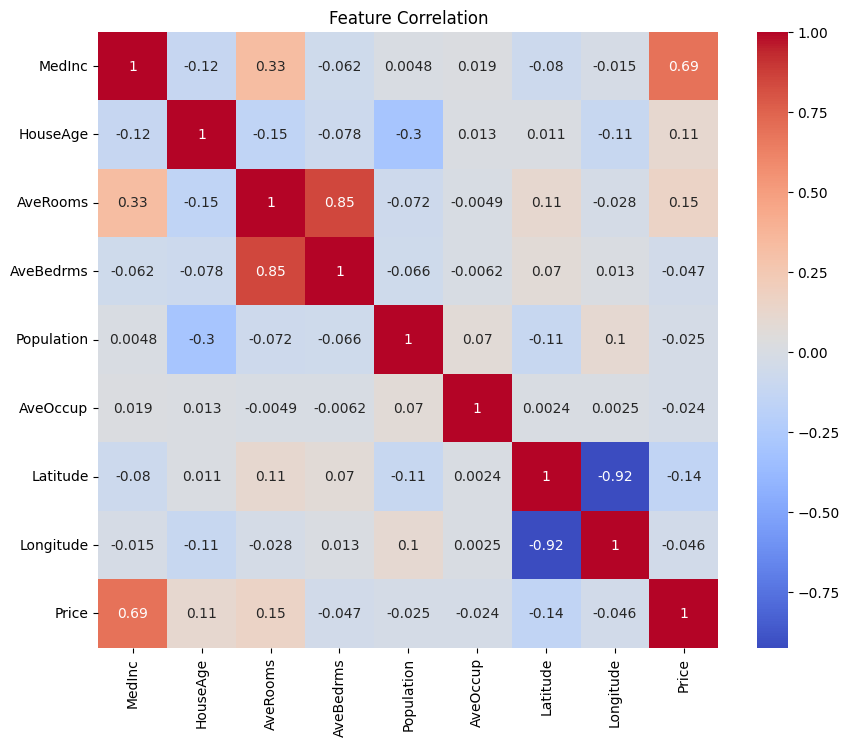

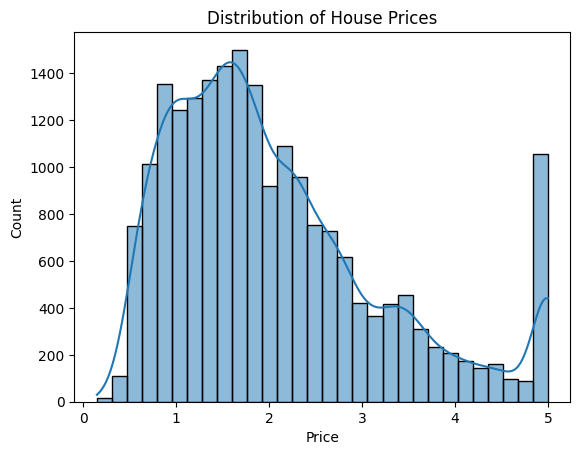

In [9]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

# Distribution of target variable
sns.histplot(df['Price'], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Split data
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Models
lr = LinearRegression()
rf = RandomForestRegressor(random_state=42)

# Train
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [4]:
from sklearn.model_selection import cross_val_score

lr_scores = cross_val_score(lr, X, y, cv=5)
rf_scores = cross_val_score(rf, X, y, cv=5)

print("Linear Regression CV Score:", lr_scores.mean())
print("Random Forest CV Score:", rf_scores.mean())

Linear Regression CV Score: 0.5530311140279569
Random Forest CV Score: 0.6561120102046164


In [5]:
from sklearn.metrics import mean_squared_error, r2_score
# Predictions
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
# Evaluation
print("Linear Regression R2:", r2_score(y_test, lr_pred))
print("Random Forest R2:", r2_score(y_test, rf_pred))
print("Linear Regression MSE:", mean_squared_error(y_test, lr_pred))
print("Random Forest MSE:", mean_squared_error(y_test, rf_pred))

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

Linear Regression R2: 0.5757877060324508
Random Forest R2: 0.8051230593157366
Linear Regression MSE: 0.5558915986952444
Random Forest MSE: 0.2553684927247781
Best Parameters: {'max_depth': None, 'n_estimators': 100}


In [ ]:
# Simple user input
def predict_price():
    print("Enter housing data:")

    values = []
    for col in X.columns:
        val = float(input(f"{col}: "))
        values.append(val)

    prediction = best_model.predict([values])
    print("Predicted House Price:", prediction[0])

# Run function
predict_price()

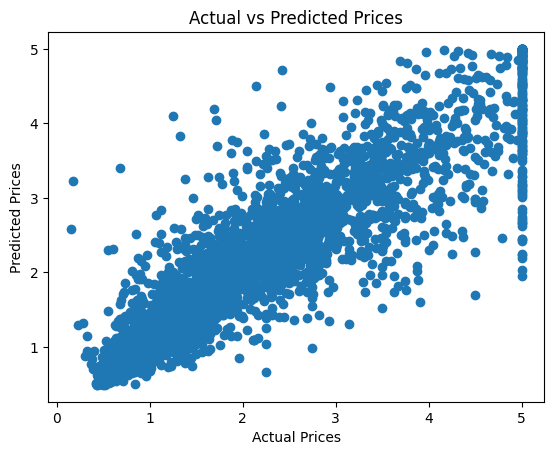

In [6]:
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()